In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
import matplotlib.pyplot as plt
from ariel_pred.config import CalibrationConfig, Config
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SergeiDataSmoother
from ariel_pred.transit import WindowBasedPhaseDetector
from scipy.signal import savgol_filter
from ariel_pred.features import SergeiOldFeaturesExtractor
import numpy as np

In [3]:
global_config = Config()
calibration_config = CalibrationConfig(
    data_path=global_config.DATA_PATH,
    airs_lower_channel=0,
    airs_upper_channel=356,
    preprocessing_n_jobs=4,
)
signal_processor = DataLoaderAndCalibrator(cfg=calibration_config)
train_data = signal_processor.process_all_data("train")
test_data = signal_processor.process_all_data("test")
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

QUEUEING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/9 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/9 [00:00<?, ?it/s]

...

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Train data shape: (9, 5625, 357)
Test data shape: (1, 5625, 357)


In [4]:
data_smoother = SergeiDataSmoother(window_size=3)
smoothed_train_data = np.array([data_smoother.smooth(signal) for signal in train_data])

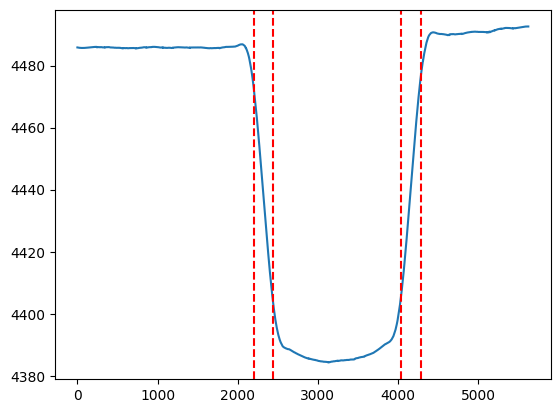

In [10]:
signal = smoothed_train_data[0].copy()
signal = signal.mean(axis=1)
signal = savgol_filter(signal, 330, 3)

transit_detector = WindowBasedPhaseDetector()
transit_drop_begin, transit_drop_end, transit_rise_begin, transit_rise_end = transit_detector.phase_detect(
    signal
)

plt.plot(signal)
plt.axvline(transit_drop_begin, color="red", linestyle="--")
plt.axvline(transit_drop_end, color="red", linestyle="--")
plt.axvline(transit_rise_begin, color="red", linestyle="--")
plt.axvline(transit_rise_end, color="red", linestyle="--")
plt.show()

In [11]:
print(f"Transit drop begin: {transit_drop_begin}")
print(f"Transit drop end: {transit_drop_end}")
print(f"Transit rise begin: {transit_rise_begin}")
print(f"Transit rise end: {transit_rise_end}")

Transit drop begin: 2200
Transit drop end: 2439
Transit rise begin: 4041
Transit rise end: 4280


In [12]:
smoothed_train_data.shape

(9, 5625, 283)

In [31]:
feature_extractor = SergeiOldFeaturesExtractor(phase_detector=transit_detector)
features = feature_extractor.extract_features(smoothed_train_data)

100%|██████████| 9/9 [00:14<00:00,  1.60s/it]


In [32]:
features.shape

(9, 283, 9)